# Linear Regression: Federated vs Centralized Analysis (ALL DATA)

This notebook compares federated and centralized linear regression models trained on ALL data (including anomalies).

**Key differences from normal data notebook:**
- Trains on all data including anomalies
- Uses fixed scaling with `include_anomalies=True`
- Thresholds calculated on normal training data only (not adaptive)
- Anomalies only in temperature (target variable)

In [1]:
# --- Main Configuration Cell ---

# 1. Data Generation Settings
DATA_CONFIG = {
    'output_dir': 'data',
    'num_aircraft': 5,
    'num_anomalous_aircraft': 1,
    'flight_duration_hours': 4,
    'points_per_hour': 60,
    'sensor_names': ['engine_rpm', 'fuel_flow', 'engine_temperature', 'vibration_level'],
    'input_sensors': ['engine_rpm', 'fuel_flow', 'vibration_level'],
    'target_sensor': 'engine_temperature'
}

# 2. Model Architecture
MODEL_CONFIG = {
    'input_dim': 3,
    'output_dim': 1
}

# 3. Training Parameters
TRAINING_CONFIG = {
    'centralized_epochs': 50,
    'federated_rounds': 10,
    'federated_local_epochs': 5,
    'learning_rate': 0.001,
}

print("✅ Configuration loaded.")

✅ Configuration loaded.


In [2]:
import os
import shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from anomfl.data_generation.aircraft_data_generator import Fleet
from anomfl.autoencoders.linear_regression import LinearRegression
from anomfl.federated.linear_regression_server import LinearRegressionFederatedClient, LinearRegressionCentralizedServer
print("Libraries imported.")

Libraries imported.


In [3]:
# --- Fixed Scaling Import ---
from anomfl.utils.fixed_scaling import get_aircraft_scaler
print("✅ Fixed scaling utilities imported")

✅ Fixed scaling utilities imported


In [4]:
print("--- Starting Data Generation ---")

# Clean up old data directory
if os.path.exists(DATA_CONFIG['output_dir']):
    shutil.rmtree(DATA_CONFIG['output_dir'])

# Calculate parameters for the Fleet class
FLEET_ID = 1
num_points = DATA_CONFIG['flight_duration_hours'] * DATA_CONFIG['points_per_hour']
interval_minutes = 60 // DATA_CONFIG['points_per_hour']

# Create the Fleet object
fleet = Fleet(
    fleet_id=FLEET_ID,
    num_aircraft=DATA_CONFIG['num_aircraft'],
    num_anomalous=DATA_CONFIG['num_anomalous_aircraft'],
    num_points=num_points,
    interval_minutes=interval_minutes,
    anomaly_features=['engine_temperature']
)

# Generate and save the data
fleet.generate_fleet_data(output_dir=DATA_CONFIG['output_dir'])

# Store file paths for later use
anomalous_ids = {record['aircraft_id'] for record in fleet.anomaly_records}
file_paths = []
for aircraft in fleet.aircraft_list:
    suffix = "_anomalous.csv" if aircraft.id in anomalous_ids else "_normal.csv"
    path = os.path.join(DATA_CONFIG['output_dir'], f"fleet_{FLEET_ID}", f"aircraft_{FLEET_ID}_{aircraft.id}{suffix}")
    file_paths.append(path)

print(f"\n✅ Data generation complete.")

--- Starting Data Generation ---
Dataset saved as d:\DL\FL\AnomFL\examples\data\fleet_1\aircraft_1_1_normal.csv
Aircraft 1-1 generated (Normal)
Dataset saved as d:\DL\FL\AnomFL\examples\data\fleet_1\aircraft_1_2_anomalous.csv
Aircraft 1-2 generated (Anomalous)
Dataset saved as d:\DL\FL\AnomFL\examples\data\fleet_1\aircraft_1_3_normal.csv
Aircraft 1-3 generated (Normal)
Dataset saved as d:\DL\FL\AnomFL\examples\data\fleet_1\aircraft_1_4_normal.csv
Aircraft 1-4 generated (Normal)
Dataset saved as d:\DL\FL\AnomFL\examples\data\fleet_1\aircraft_1_5_normal.csv
Aircraft 1-5 generated (Normal)
Anomaly summary saved as d:\DL\FL\AnomFL\examples\data\fleet_1\fleet_1_anomalies.csv

✅ Data generation complete.


In [5]:
print("--- Training Centralized Model (ALL DATA) ---")

all_file_paths = file_paths
print(f"Loading data from {len(all_file_paths)} aircraft files:")
for i, path in enumerate(all_file_paths):
    print(f"  Aircraft {i+1}: {os.path.basename(path)}")

all_dfs = [pd.read_csv(path) for path in all_file_paths]
all_data_df = pd.concat(all_dfs, ignore_index=True)
input_data = all_data_df[DATA_CONFIG['input_sensors']]
target_data = all_data_df[[DATA_CONFIG['target_sensor']]]

input_scaler = get_aircraft_scaler(include_anomalies=True)
target_scaler = get_aircraft_scaler(include_anomalies=True)
scaled_input = input_scaler.transform(input_data)
scaled_target = target_scaler.transform(target_data)
input_tensor = torch.tensor(scaled_input, dtype=torch.float32)
target_tensor = torch.tensor(scaled_target, dtype=torch.float32)

centralized_model = LinearRegression(
    input_dim=MODEL_CONFIG['input_dim'],
    output_dim=MODEL_CONFIG['output_dim']
)
centralized_model.train_on_tensor(
    input_tensor,
    target_tensor,
    num_epochs=TRAINING_CONFIG['centralized_epochs'],
    lr=TRAINING_CONFIG['learning_rate']
)

centralized_model.eval()
with torch.no_grad():
    predicted = centralized_model(input_tensor)
    final_loss = nn.MSELoss()(predicted, target_tensor)
print(f"Final MSE on All Training Data (Centralized): {final_loss.item():.8f}")

--- Training Centralized Model (ALL DATA) ---
Loading data from 5 aircraft files:
  Aircraft 1: aircraft_1_1_normal.csv
  Aircraft 2: aircraft_1_2_anomalous.csv
  Aircraft 3: aircraft_1_3_normal.csv
  Aircraft 4: aircraft_1_4_normal.csv
  Aircraft 5: aircraft_1_5_normal.csv
Starting training...
  Epoch [10/50], Loss: 0.000705
  Epoch [20/50], Loss: 0.000350
  Epoch [30/50], Loss: 0.000876
  Epoch [40/50], Loss: 0.000443
  Epoch [50/50], Loss: 0.000468
Final MSE on All Training Data (Centralized): 0.00115192


In [6]:
print("--- Training Federated Model ---")

clients = [
    LinearRegressionFederatedClient(client_id=i + 1, file_path=file_paths[i], target_sensor=DATA_CONFIG['target_sensor'])
    for i in range(DATA_CONFIG['num_aircraft'])
]
base_model = LinearRegression(
    input_dim=MODEL_CONFIG['input_dim'],
    output_dim=MODEL_CONFIG['output_dim']
)
server = LinearRegressionCentralizedServer(clients=clients, model=base_model)
server.train(
    rounds=TRAINING_CONFIG['federated_rounds'],
    local_epochs=TRAINING_CONFIG['federated_local_epochs'],
    lr=TRAINING_CONFIG['learning_rate']
)
federated_model = server.global_model

federated_model.eval()
with torch.no_grad():
    predicted = federated_model(input_tensor)
    final_loss = nn.MSELoss()(predicted, target_tensor)
print(f"Final MSE on All Training Data (Federated): {final_loss.item():.8f}")

--- Training Federated Model ---

ROUND 1/10
  -> Training Client 1...
    Epoch [2/5], Client Loss: 0.360390
    Epoch [4/5], Client Loss: 0.339187
  -> Training Client 2...
    Epoch [2/5], Client Loss: 0.044408
    Epoch [4/5], Client Loss: 0.050846
  -> Training Client 3...
    Epoch [2/5], Client Loss: 0.318959
    Epoch [4/5], Client Loss: 0.383735
  -> Training Client 4...
    Epoch [2/5], Client Loss: 0.371726
    Epoch [4/5], Client Loss: 0.343241
  -> Training Client 5...
    Epoch [2/5], Client Loss: 0.187632
    Epoch [4/5], Client Loss: 0.142699

ROUND 2/10
  -> Training Client 1...
    Epoch [2/5], Client Loss: 0.251779
    Epoch [4/5], Client Loss: 0.356900
  -> Training Client 2...
    Epoch [2/5], Client Loss: 0.025783
    Epoch [4/5], Client Loss: 0.005147
  -> Training Client 3...
    Epoch [2/5], Client Loss: 0.265595
    Epoch [4/5], Client Loss: 0.196473
  -> Training Client 4...
    Epoch [2/5], Client Loss: 0.255885
    Epoch [4/5], Client Loss: 0.286843
  -> Tr

--- Generating Comparison Plots ---


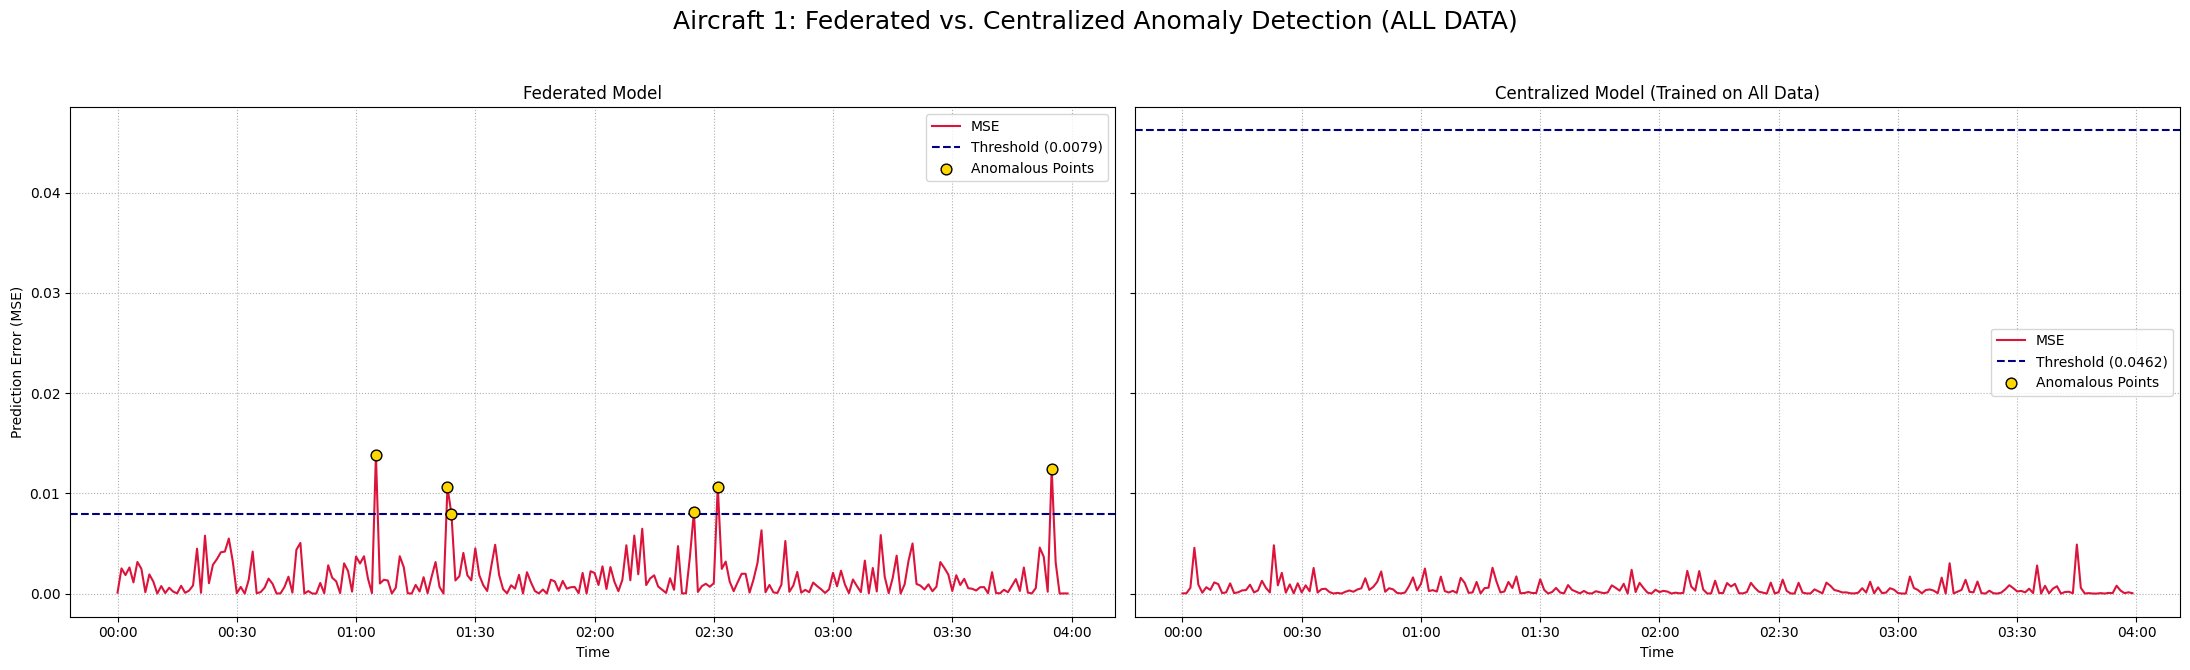


Aircraft 1 (Normal):
  Federated - Anomalies detected: 6
  Centralized - Anomalies detected: 0


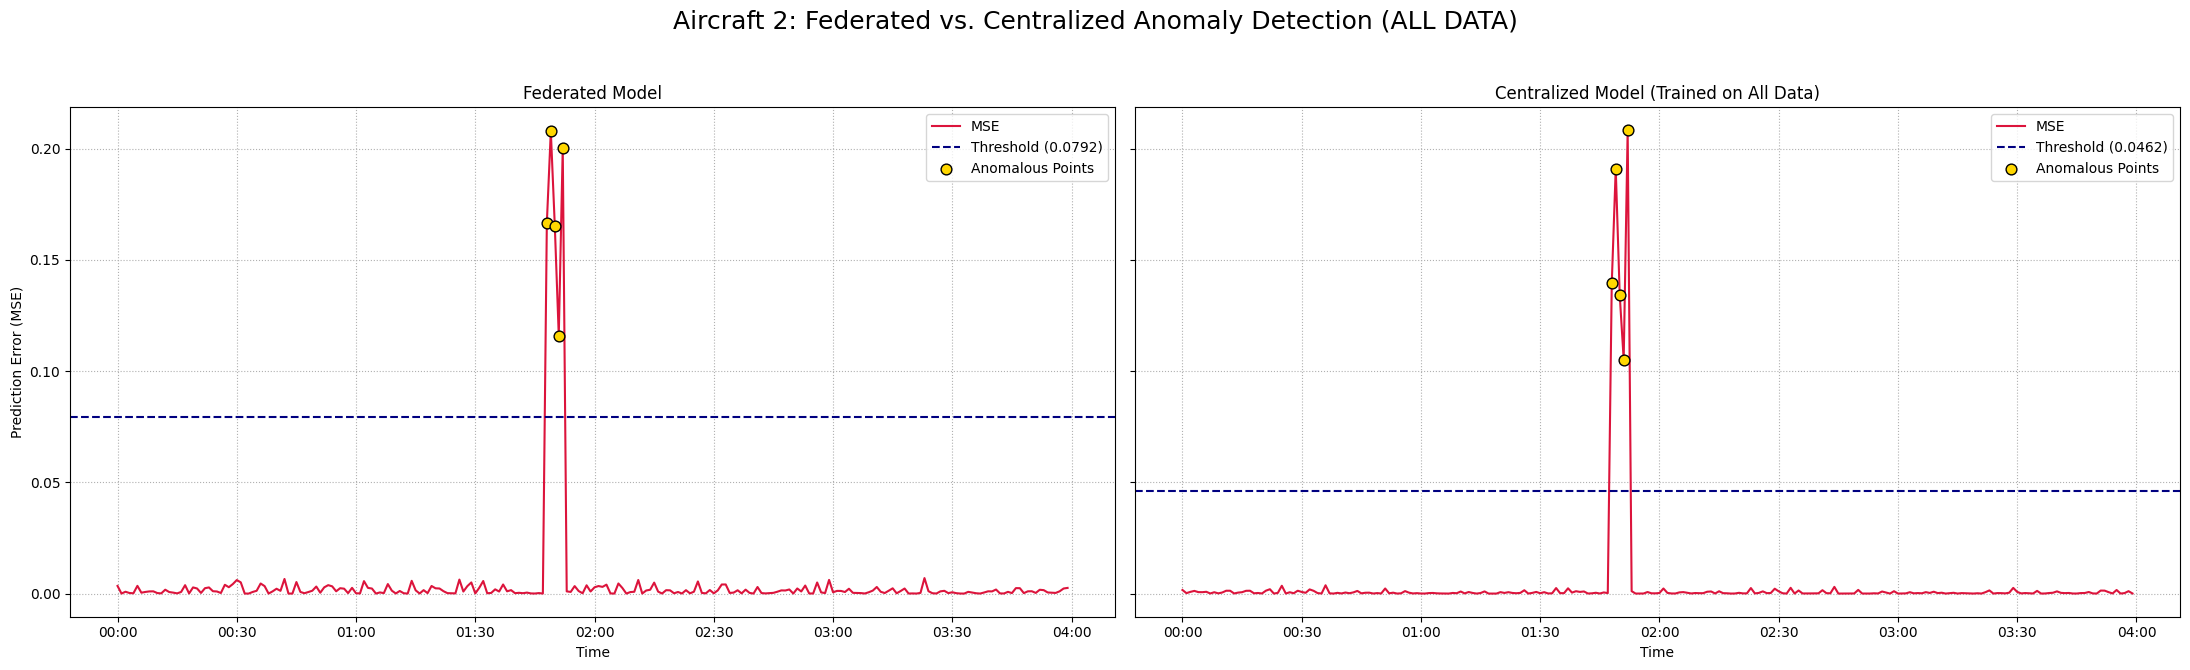


Aircraft 2 (Anomalous):
  Federated - Anomalies detected: 5
  Centralized - Anomalies detected: 5


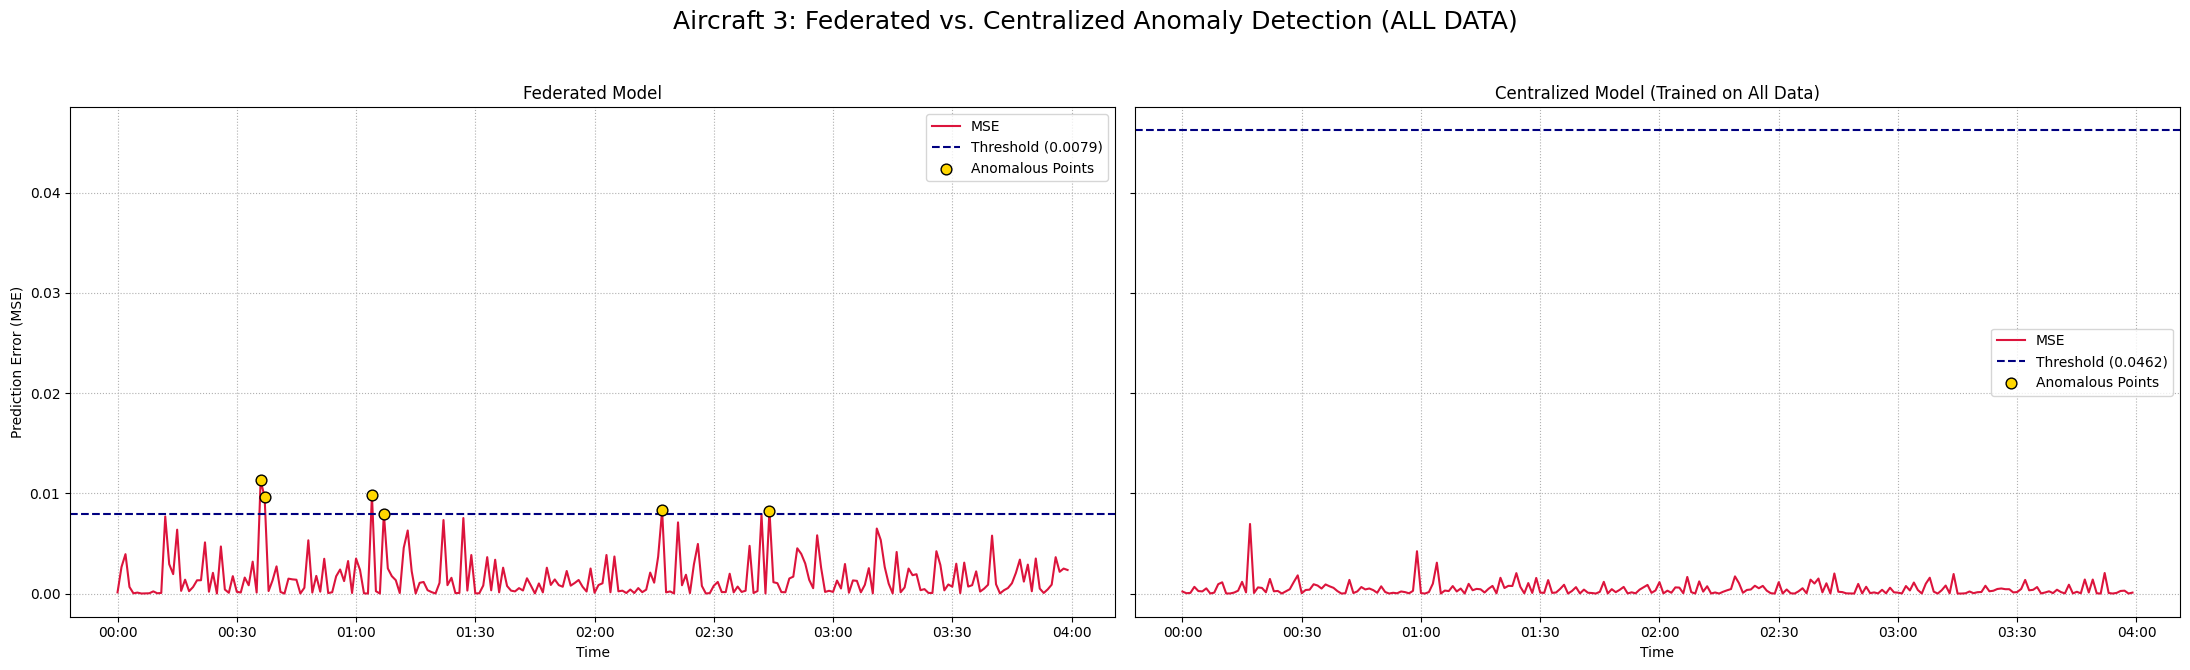


Aircraft 3 (Normal):
  Federated - Anomalies detected: 6
  Centralized - Anomalies detected: 0


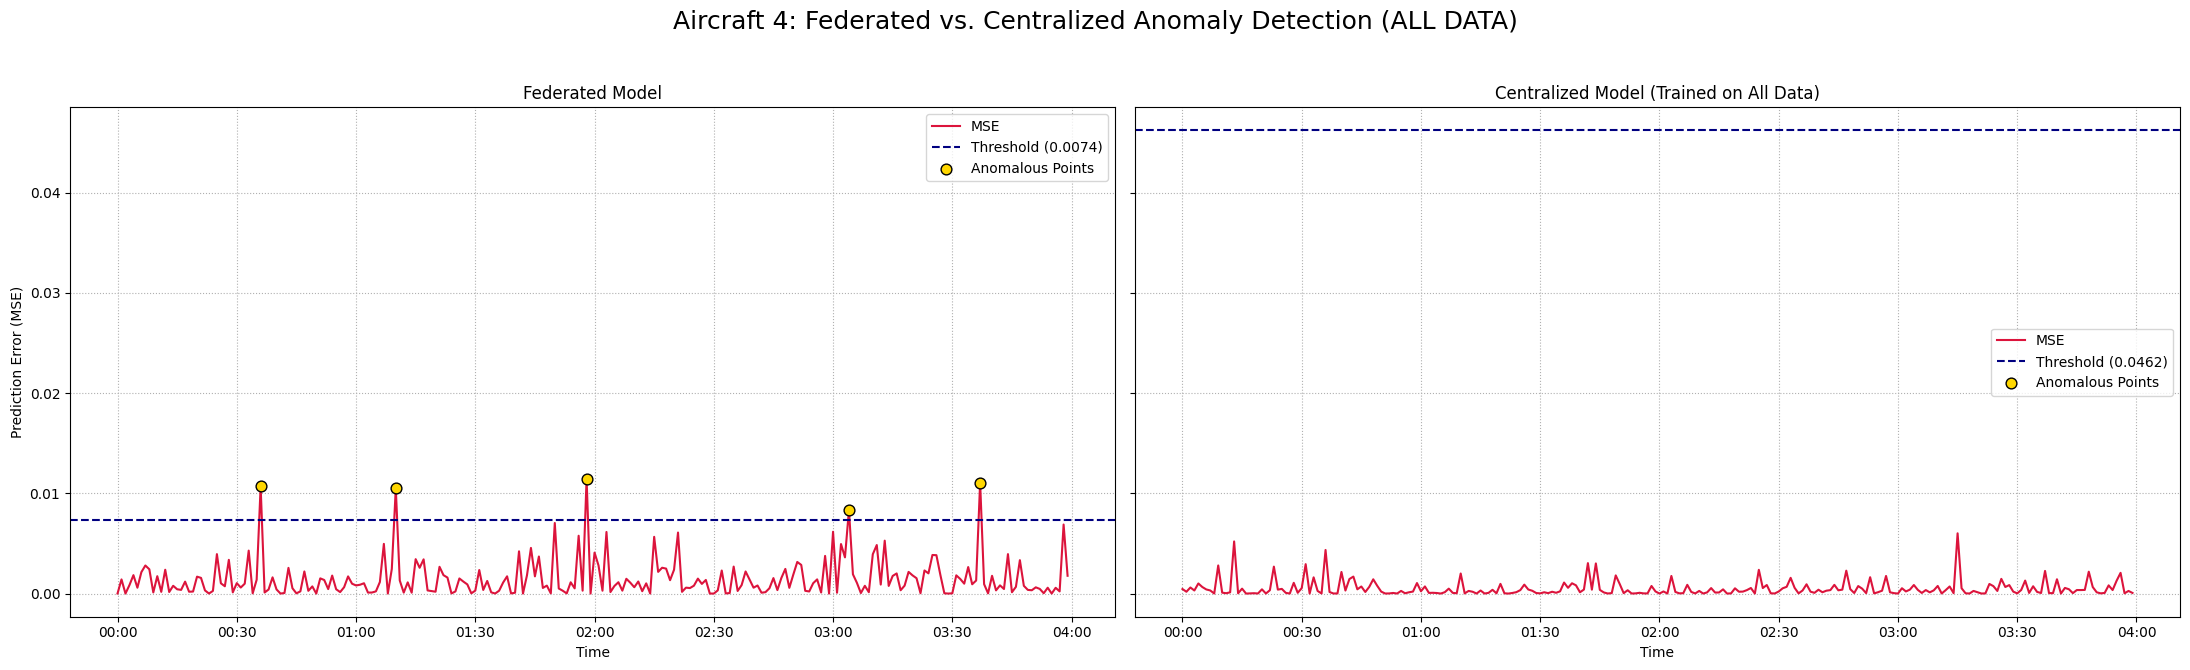


Aircraft 4 (Normal):
  Federated - Anomalies detected: 5
  Centralized - Anomalies detected: 0


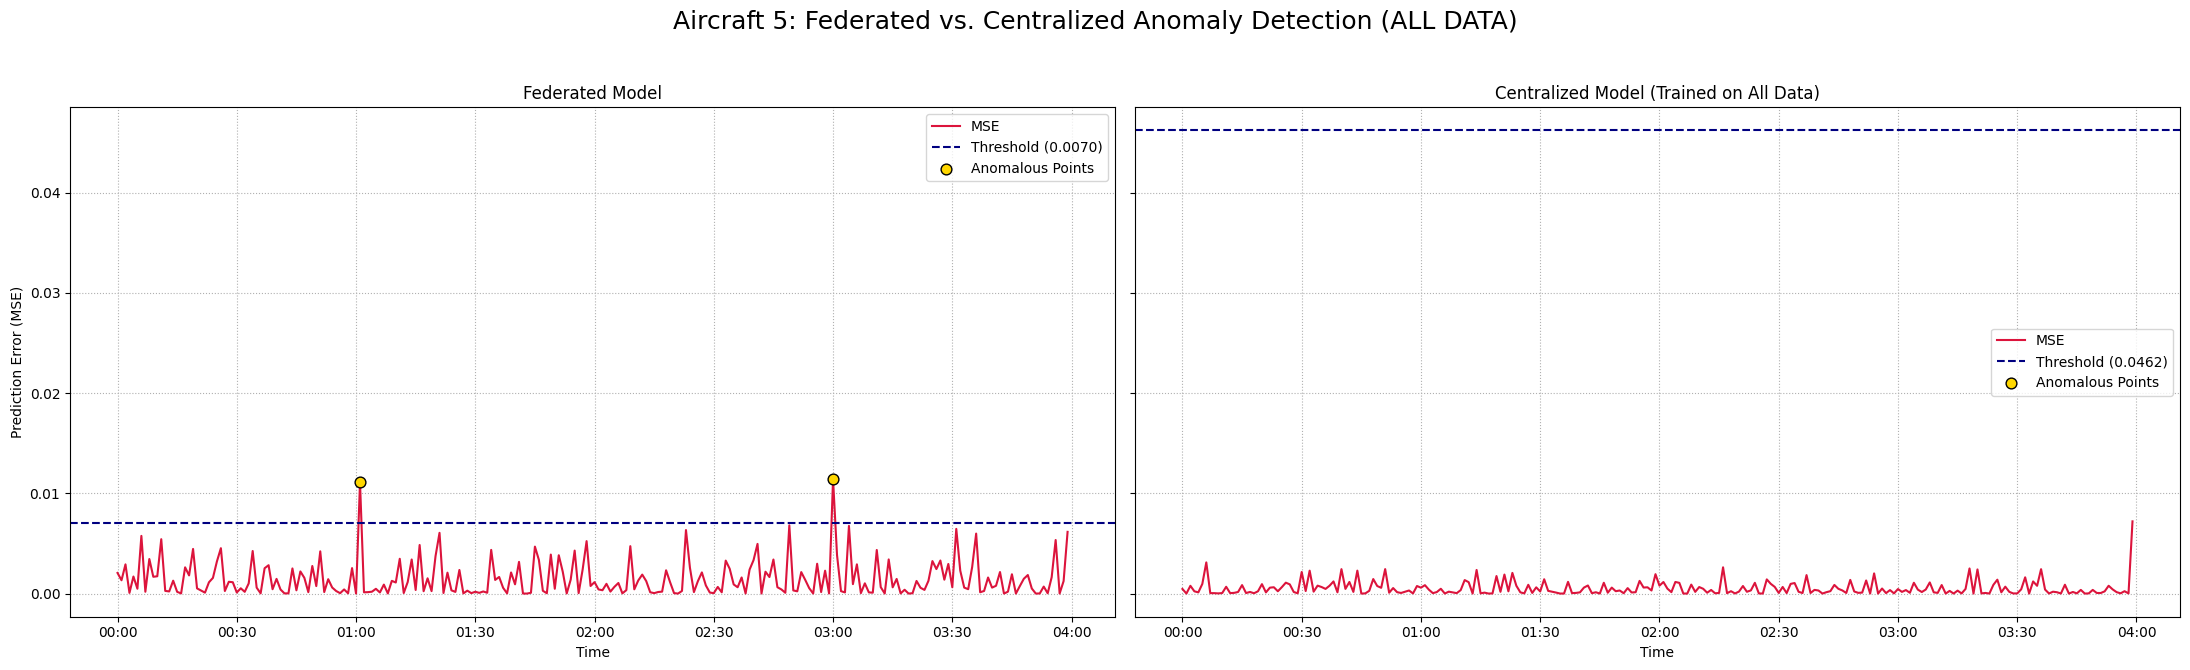


Aircraft 5 (Normal):
  Federated - Anomalies detected: 2
  Centralized - Anomalies detected: 0


In [7]:
print("--- Generating Comparison Plots ---")

def get_errors(model, input_tensor, target_tensor):
    with torch.no_grad():
        model.eval()
        predicted = model(input_tensor)
        return torch.mean((target_tensor - predicted)**2, dim=1).numpy()

for i, file_path in enumerate(file_paths):
    client_id = i + 1
    client_df = pd.read_csv(file_path)
    timestamps = pd.to_datetime(client_df['timestamp'])
    client_input = client_df[DATA_CONFIG['input_sensors']]
    client_target = client_df[[DATA_CONFIG['target_sensor']]]
    scaled_input = input_scaler.transform(client_input)
    scaled_target = target_scaler.transform(client_target)
    input_tensor = torch.tensor(scaled_input, dtype=torch.float32)
    target_tensor = torch.tensor(scaled_target, dtype=torch.float32)
    
    fed_errors = get_errors(federated_model, input_tensor, target_tensor)
    fed_threshold = np.mean(fed_errors) + 3 * np.std(fed_errors)
    fed_anomalies = fed_errors > fed_threshold
    
    cen_errors = get_errors(centralized_model, input_tensor, target_tensor)
    # FIXED: Use normal training data for threshold calculation instead of adaptive threshold
    # Get normal training data for threshold calculation
    normal_paths = [p for p in file_paths if "anomalous" not in p]
    normal_dfs = [pd.read_csv(p) for p in normal_paths]
    normal_data_df = pd.concat(normal_dfs, ignore_index=True)
    normal_input = normal_data_df[DATA_CONFIG['input_sensors']]
    normal_target = normal_data_df[[DATA_CONFIG['target_sensor']]]
    
    # Use normal ranges for threshold calculation
    normal_input_scaler = get_aircraft_scaler(include_anomalies=False)
    normal_target_scaler = get_aircraft_scaler(include_anomalies=False)
    
    scaled_normal_input = normal_input_scaler.transform(normal_input)
    scaled_normal_target = normal_target_scaler.transform(normal_target)
    
    normal_input_tensor = torch.tensor(scaled_normal_input, dtype=torch.float32)
    normal_target_tensor = torch.tensor(scaled_normal_target, dtype=torch.float32)
    
    normal_training_errors = get_errors(centralized_model, normal_input_tensor, normal_target_tensor)
    cen_threshold = np.mean(normal_training_errors) + 3 * np.std(normal_training_errors)
    cen_anomalies = cen_errors > cen_threshold
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 7), sharey=True)
    fig.suptitle(f'Aircraft {client_id}: Federated vs. Centralized Anomaly Detection (ALL DATA)', fontsize=18)
    
    ax1.plot(timestamps, fed_errors, label='MSE', color='crimson')
    ax1.axhline(fed_threshold, color='navy', linestyle='--', label=f'Threshold ({fed_threshold:.4f})')
    ax1.scatter(timestamps[fed_anomalies], fed_errors[fed_anomalies], s=60, color='gold', edgecolor='black', label='Anomalous Points', zorder=5)
    ax1.set_title('Federated Model')
    ax1.set_ylabel("Prediction Error (MSE)")
    ax1.set_xlabel("Time")
    ax1.grid(True, which='both', linestyle=':')
    ax1.legend()
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    
    ax2.plot(timestamps, cen_errors, label='MSE', color='crimson')
    ax2.axhline(cen_threshold, color='navy', linestyle='--', label=f'Threshold ({cen_threshold:.4f})')
    ax2.scatter(timestamps[cen_anomalies], cen_errors[cen_anomalies], s=60, color='gold', edgecolor='black', label='Anomalous Points', zorder=5)
    ax2.set_title('Centralized Model (Trained on All Data)')
    ax2.set_xlabel("Time")
    ax2.grid(True, which='both', linestyle=':')
    ax2.legend()
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    
    # Print summary for this aircraft
    status = "Anomalous" if "anomalous" in file_path else "Normal"
    print(f"\nAircraft {client_id} ({status}):")
    print(f"  Federated - Anomalies detected: {np.sum(fed_anomalies)}")
    print(f"  Centralized - Anomalies detected: {np.sum(cen_anomalies)}")

In [8]:
print("\n--- Model Performance Statistics ---")

centralized_stats = []
federated_stats = []

centralized_model.eval()
federated_model.eval()

with torch.no_grad():
    for i, file_path in enumerate(file_paths):
        client_id = i + 1
        df = pd.read_csv(file_path)
        input_data = df[DATA_CONFIG['input_sensors']]
        target_data = df[[DATA_CONFIG['target_sensor']]]
        n_points = len(input_data)
        scaled_input = input_scaler.transform(input_data)
        scaled_target = target_scaler.transform(target_data)
        input_tensor = torch.tensor(scaled_input, dtype=torch.float32)
        target_tensor = torch.tensor(scaled_target, dtype=torch.float32)
        
        predicted_centralized = centralized_model(input_tensor)
        mse_centralized = torch.mean((target_tensor - predicted_centralized)**2, dim=1)
        centralized_stats.append({
            'client_id': client_id,
            'status': 'Anomalous' if "anomalous" in file_path else 'Normal',
            'mean_mse': mse_centralized.mean().item(),
            'max_mse': mse_centralized.max().item(),
            'std_mse': mse_centralized.std().item(),
            'n_points': n_points
        })
        
        predicted_federated = federated_model(input_tensor)
        mse_federated = torch.mean((target_tensor - predicted_federated)**2, dim=1)
        federated_stats.append({
            'client_id': client_id,
            'status': 'Anomalous' if "anomalous" in file_path else 'Normal',
            'mean_mse': mse_federated.mean().item(),
            'max_mse': mse_federated.max().item(),
            'std_mse': mse_federated.std().item(),
            'n_points': n_points
        })

centralized_df = pd.DataFrame(centralized_stats).set_index('client_id')
federated_df = pd.DataFrame(federated_stats).set_index('client_id')

pd.set_option('display.float_format', '{:.6f}'.format)

print("\n--- Centralized Model Performance ---")
display(centralized_df[['status', 'mean_mse', 'max_mse', 'std_mse', 'n_points']])

print("\n--- Federated Model Performance ---")
display(federated_df[['status', 'mean_mse', 'max_mse', 'std_mse', 'n_points']])


--- Model Performance Statistics ---

--- Centralized Model Performance ---


,status,mean_mse,max_mse,std_mse,n_points
client_id,,,,,
1,Normal,0.000517,0.004891,0.000761,240
2,Anomalous,0.003718,0.208212,0.022892,240
3,Normal,0.000472,0.006942,0.000697,240
4,Normal,0.000517,0.006010,0.000815,240
5,Normal,0.000536,0.007203,0.000761,240



--- Federated Model Performance ---


,status,mean_mse,max_mse,std_mse,n_points
client_id,,,,,
1,Normal,0.001632,0.013869,0.002092,240
2,Anomalous,0.004969,0.207889,0.024807,240
3,Normal,0.001648,0.011288,0.002105,240
4,Normal,0.001510,0.011456,0.001956,240
5,Normal,0.001494,0.011403,0.001848,240



--- Visualizing Performance Statistics ---


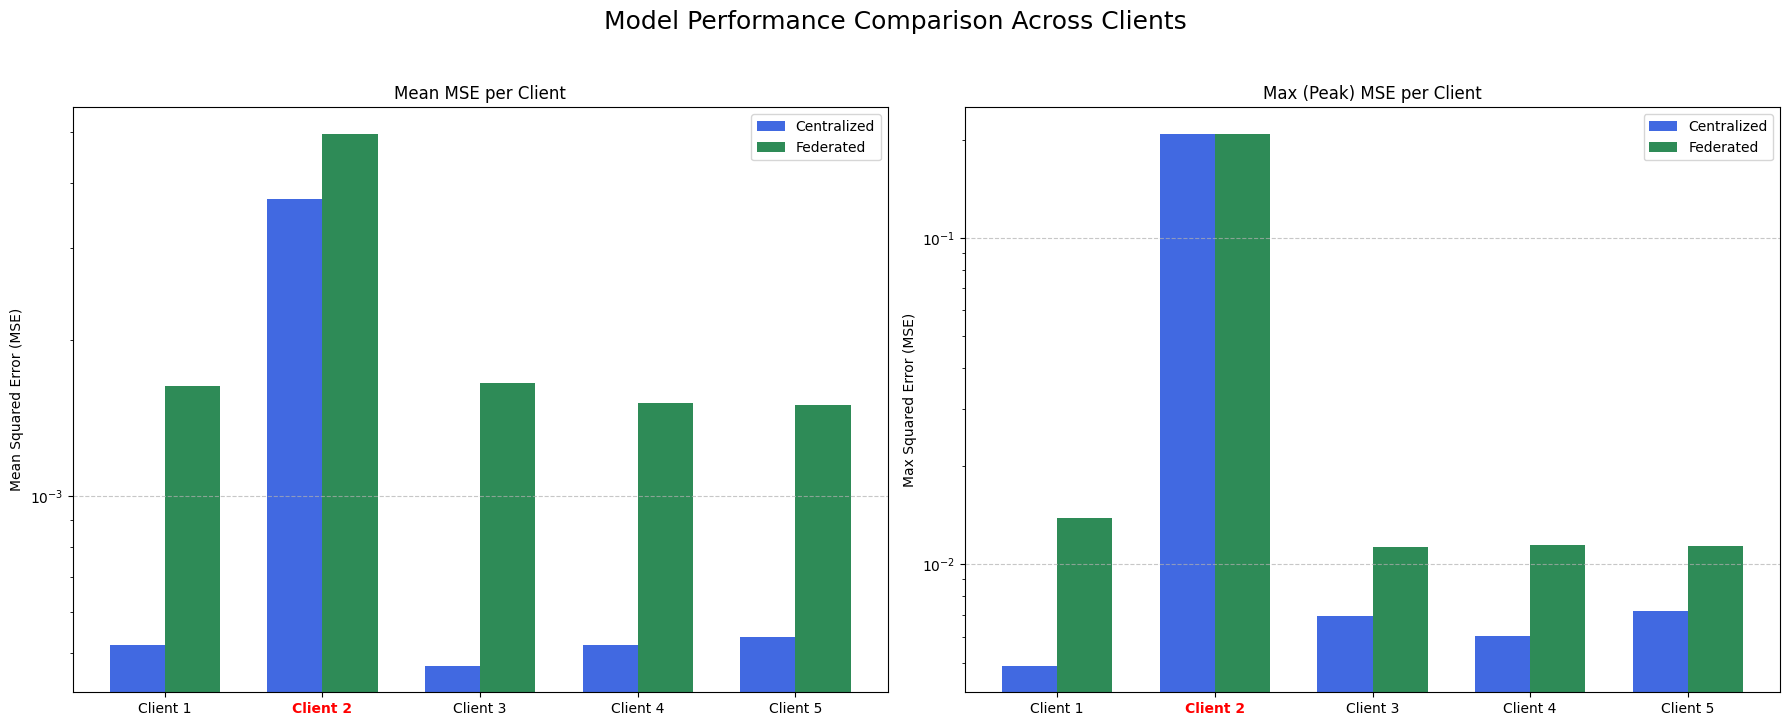

In [9]:
print("\n--- Visualizing Performance Statistics ---")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Model Performance Comparison Across Clients', fontsize=18, y=1.03)
bar_width = 0.35
client_ids = centralized_df.index
x = np.arange(len(client_ids))

rects1 = ax1.bar(x - bar_width/2, centralized_df['mean_mse'], bar_width, label='Centralized', color='royalblue')
rects2 = ax1.bar(x + bar_width/2, federated_df['mean_mse'], bar_width, label='Federated', color='seagreen')
ax1.set_ylabel('Mean Squared Error (MSE)')
ax1.set_title('Mean MSE per Client')
ax1.set_xticks(x)
ax1.set_xticklabels([f'Client {id}' for id in client_ids])
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.set_yscale('log')

rects3 = ax2.bar(x - bar_width/2, centralized_df['max_mse'], bar_width, label='Centralized', color='royalblue')
rects4 = ax2.bar(x + bar_width/2, federated_df['max_mse'], bar_width, label='Federated', color='seagreen')
ax2.set_ylabel('Max Squared Error (MSE)')
ax2.set_title('Max (Peak) MSE per Client')
ax2.set_xticks(x)
ax2.set_xticklabels([f'Client {id}' for id in client_ids])
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.set_yscale('log')

for ax in [ax1, ax2]:
    for i, client_id in enumerate(client_ids):
        if centralized_df.loc[client_id, 'status'] == 'Anomalous':
            ax.get_xticklabels()[i].set_color('red')
            ax.get_xticklabels()[i].set_weight('bold')

fig.tight_layout()
plt.show()

In [10]:
print("\n--- Simple Epoch Comparison: Federated vs Centralized ---")

epochs_to_test = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100,110,120,130,140,150,160,170,180,190,200]
results = []
print("Testing different epoch configurations...")

for epochs in epochs_to_test:
    print(f"\n--- Testing {epochs} epochs ---")
    centralized_test = LinearRegression(
        input_dim=MODEL_CONFIG['input_dim'],
        output_dim=MODEL_CONFIG['output_dim']
    )
    centralized_test.train_on_tensor(input_tensor, target_tensor, num_epochs=epochs, lr=TRAINING_CONFIG['learning_rate'])
    test_clients = [
        LinearRegressionFederatedClient(client_id=i + 1, file_path=file_paths[i], target_sensor=DATA_CONFIG['target_sensor'])
        for i in range(DATA_CONFIG['num_aircraft'])
    ]
    test_base_model = LinearRegression(
        input_dim=MODEL_CONFIG['input_dim'],
        output_dim=MODEL_CONFIG['output_dim']
    )
    test_server = LinearRegressionCentralizedServer(clients=test_clients, model=test_base_model)
    test_server.train(rounds=10, local_epochs=epochs//10, lr=TRAINING_CONFIG['learning_rate'])
    centralized_test.eval()
    test_server.global_model.eval()
    with torch.no_grad():
        cen_predicted = centralized_test(input_tensor)
        cen_mse = nn.MSELoss()(cen_predicted, target_tensor).item()
        fed_predicted = test_server.global_model(input_tensor)
        fed_mse = nn.MSELoss()(fed_predicted, target_tensor).item()
    results.append({
        'epochs': epochs,
        'centralized_mse': cen_mse,
        'federated_mse': fed_mse,
        'federated_better': fed_mse < cen_mse
    })
    print(f"   Centralized MSE: {cen_mse:.6f}")
    print(f"   Federated MSE: {fed_mse:.6f}")
    print(f"   Federated better: {fed_mse < cen_mse}")


--- Simple Epoch Comparison: Federated vs Centralized ---
Testing different epoch configurations...

--- Testing 10 epochs ---
Starting training...
  Epoch [10/10], Loss: 0.021149

ROUND 1/10
  -> Training Client 1...
  -> Training Client 2...
  -> Training Client 3...
  -> Training Client 4...
  -> Training Client 5...

ROUND 2/10
  -> Training Client 1...
  -> Training Client 2...
  -> Training Client 3...
  -> Training Client 4...
  -> Training Client 5...

ROUND 3/10
  -> Training Client 1...
  -> Training Client 2...
  -> Training Client 3...
  -> Training Client 4...
  -> Training Client 5...

ROUND 4/10
  -> Training Client 1...
  -> Training Client 2...
  -> Training Client 3...
  -> Training Client 4...
  -> Training Client 5...

ROUND 5/10
  -> Training Client 1...
  -> Training Client 2...
  -> Training Client 3...
  -> Training Client 4...
  -> Training Client 5...

ROUND 6/10
  -> Training Client 1...
  -> Training Client 2...
  -> Training Client 3...
  -> Training Clien

In [11]:
results_df = pd.DataFrame(results)
print("\n--- Results Summary ---")
display(results_df)
crossover_found = False
for i, row in results_df.iterrows():
    if row['federated_better']:
        print(f"\n🎯 CROSSOVER POINT FOUND!")
        print(f"   Federated Learning becomes better at {row['epochs']} epochs")
        print(f"   Centralized MSE: {row['centralized_mse']:.6f}")
        print(f"   Federated MSE: {row['federated_mse']:.6f}")
        crossover_found = True
        break
if not crossover_found:
    print("\n❌ No crossover point found in tested range")


--- Results Summary ---


,epochs,centralized_mse,federated_mse,federated_better
0,10,0.020095,0.001173,True
1,20,0.067748,0.099526,False
2,30,0.338704,0.017520,True
3,40,0.000500,0.015814,False
4,50,0.006199,0.000845,True
5,60,0.000784,0.040620,False
6,70,0.005184,0.001915,True
7,80,0.000782,0.043797,False
8,90,0.000997,0.002969,False
9,100,0.001388,0.008416,False



🎯 CROSSOVER POINT FOUND!
   Federated Learning becomes better at 10 epochs
   Centralized MSE: 0.020095
   Federated MSE: 0.001173


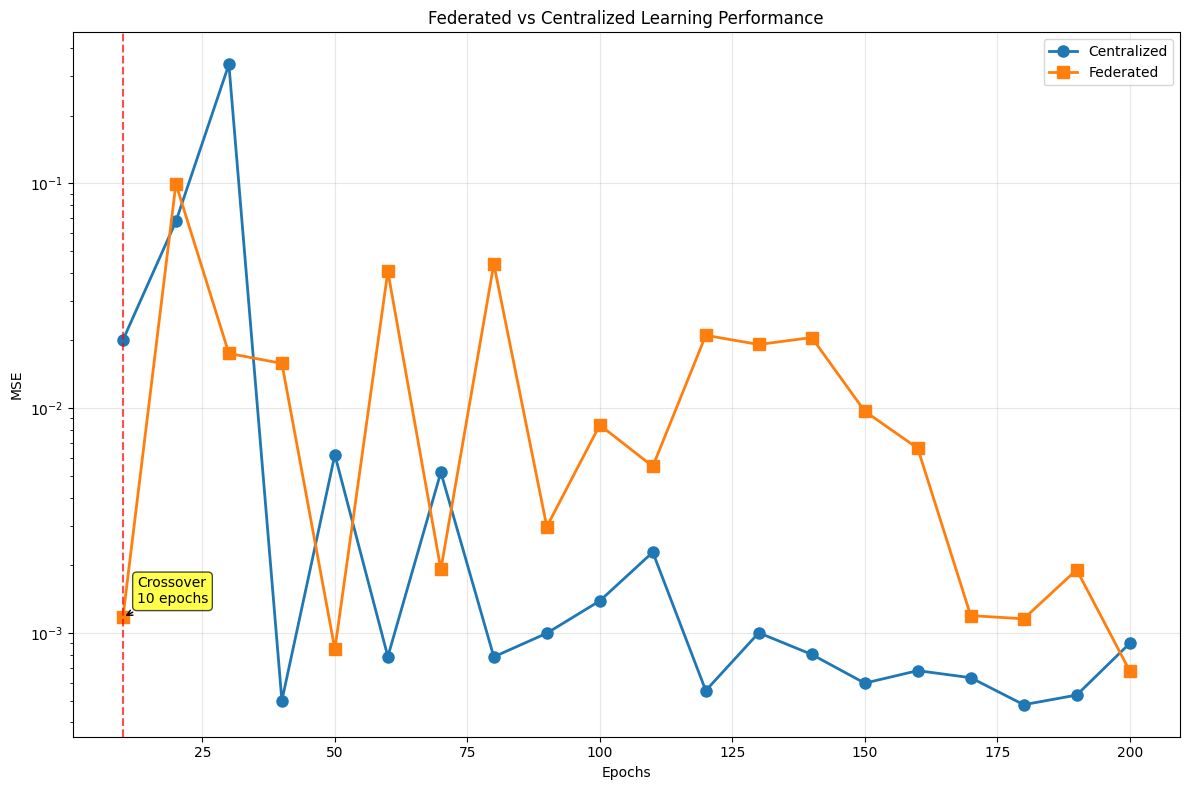

In [12]:
plt.figure(figsize=(12, 8))
plt.plot(results_df['epochs'], results_df['centralized_mse'], marker='o', label='Centralized', linewidth=2, markersize=8)
plt.plot(results_df['epochs'], results_df['federated_mse'], marker='s', label='Federated', linewidth=2, markersize=8)
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('Federated vs Centralized Learning Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
if crossover_found:
    for i, row in results_df.iterrows():
        if row['federated_better']:
            plt.axvline(x=row['epochs'], color='red', linestyle='--', alpha=0.7, label=f'Crossover at {row["epochs"]} epochs')
            plt.annotate(f'Crossover\n{row["epochs"]} epochs', xy=(row['epochs'], row['federated_mse']), xytext=(10, 10), textcoords='offset points', bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7), arrowprops=dict(arrowstyle='->'))
            break
plt.tight_layout()
plt.show()